# CNeuroMod citations

Papers using CNeuroMod data, by year and publication type. Reads `cneuromod_citations.csv`
(written by `invoke run-citations`) and renders the `citations_by_year.png` panel of the
montage, sized from `panel_sizes.json` so it is placed 1:1 (see CLAUDE.md, "Figures: the
Inkscape montage pattern").

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from airoh.figures import panel_size

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()
figures_dir = Path(os.environ.get("FIGURES_DIR", output_dir / "figures")).resolve()
dpi = int(os.environ.get("FIGURE_MONTAGE_DPI", 300))

# Every output of this notebook goes in its own folder: run-notebooks uses it
# as the "already ran" marker.
panel_dir = figures_dir / "cneuromod_citations"
panel_dir.mkdir(parents=True, exist_ok=True)

citations = pd.read_csv(output_dir / "cneuromod_citations.csv")
citations

,year,type,count
0,2020.0,Thesis,1
1,2022.0,Conference,1
2,2022.0,Journal,2
3,2023.0,Conference,1
4,2023.0,Journal,3
5,2023.0,Preprint,2
6,2023.0,Thesis,1
7,2024.0,Journal,1
8,2024.0,Preprint,2
9,2024.0,Thesis,1


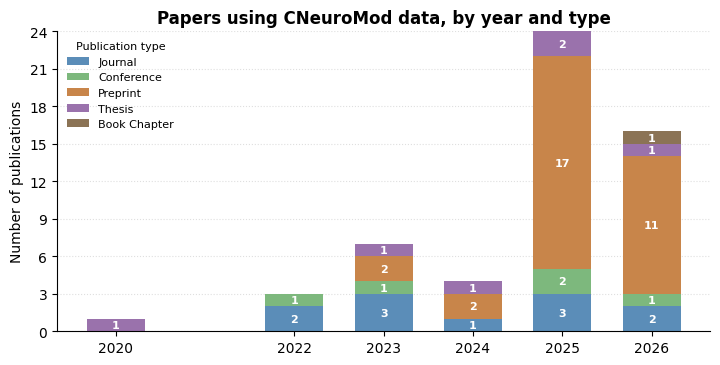

Saved /home/pbellec/git/cneuromod.paper/source_data/reuse_stats/output_data/figures/cneuromod_citations/citations_by_year.png


In [2]:
TYPE_ORDER = ["Journal", "Conference", "Preprint", "Thesis", "Book Chapter", "Other"]
TYPE_COLORS = {
    "Journal": "#5B8DB8",
    "Conference": "#7DB87D",
    "Preprint": "#C8854A",
    "Thesis": "#9A72AC",
    "Book Chapter": "#8B7355",
    "Other": "#AAAAAA",
}

# rows = year, columns = publication type. Entries without a year cannot be
# placed on the axis, so they are dropped before choosing the legend entries.
dated = citations.dropna(subset=["year"])
counts_by_year = (
    dated
    .pivot_table(index="year", columns="type", values="count", aggfunc="sum", fill_value=0)
    .reindex(columns=[t for t in TYPE_ORDER if t in set(dated["type"])], fill_value=0)
    .sort_index()
)
years = counts_by_year.index.astype(int).tolist()

panel_name = "cneuromod_citations/citations_by_year.png"
fig, ax = plt.subplots(figsize=panel_size(panel_name, (8, 4)), layout="constrained")

bottom = np.zeros(len(years))
for publication_type in counts_by_year.columns:
    type_counts = counts_by_year[publication_type].to_numpy()
    bars = ax.bar(
        years, type_counts, bottom=bottom,
        color=TYPE_COLORS.get(publication_type, "#888888"),
        label=publication_type, width=0.65, zorder=2,
    )
    for bar, count in zip(bars, type_counts):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                str(int(count)), ha="center", va="center",
                fontsize=8, fontweight="bold", color="white", zorder=3,
            )
    bottom += type_counts

ax.set_xticks(years)
ax.set_xticklabels([str(year) for year in years])
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel("Number of publications")
ax.set_title("Papers using CNeuroMod data, by year and type", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False, fontsize=8,
          title="Publication type", title_fontsize=8)

# No bbox_inches="tight": it would resize the canvas and break 1:1 placement.
out_path = figures_dir / panel_name
fig.savefig(out_path, dpi=dpi)
plt.show()
print(f"Saved {out_path}")